# Apartment-Level Floor Plan Dataset Derived From MSD

In this notebook, we convert MSD into a information-rich and easy-to-work with dataset of apartment-level floor plans.
The notebook contains the following sections:

**(1) Apartment-level graph extraction.**
From the table (.csv) associated with the MSD floor plan dataset, we extract all distinct apartments that can be found in there (i.e., we develop a function that filters all the building elements corresponding to a particular apartment ID).
Each apartment (i.e., list of building elements) is subsequently converted into a richly-attributed graph, where nodes represent rooms and edges their relations.
Node attributes include the room's geometry and function.
Edge attributes include the type of connectivity and the associated geometry (e.g., geometry of the door) if such a geometry exists in the first place.
Graph-level attributes include the floor ID, apartment ID, and the sets of walls and windows (as geometries) that 'built' the apartment.
We have developed some sophisticated plotting functions in which it is remarkably easy to include your own coloring scheme, and which type of elements you want to be visualized (e.g., whether you want to see back walls, windows, doors, or entrances).

**(2) Filtering.**
In here we remove apartments that are too small or too large ($5 \leq N \leq 12 $, $N$ is the number of rooms), that are not connected (i.e., there exist two, or more, subgraphs that do not share any edge between their corresponding sets of nodes).


**(3) Meta-data analysis.**
In this section, we provide some meta-data about the apartment-level floor plan dataset.
These meta-data regards mostly distributions, such as the distribution of the number of rooms (numeric).



## (1) Apartment-level graph extraction

This part explains how to extract the apartment-level graphs from the corresponding dataframe of MSD and, subsequently, how to nicely visualize the layouts and corresponding connectivity from these graphs.

The graph extraction algorithm in this notebook is slightly different from the one in our Github ($\longrightarrow$ [Data Curation Part 2 - Graph Extraction](https://github.com/caspervanengelenburg/msd/blob/main/NB%20-%20Data%20Curation%202%20-%20Graph%20Extraction.ipynb)):
We include more features / attributes to the nodes, edges, and the graph itself (1) and the room categorizations are slightly different (2).
The format of the data stays the same; so, if you already worked with the other graph data, it won't be difficult to modify the code to work with the ones we'll extract here.

### Loading dataframe

Here we load the MSD dataset, which is already cleaned and filtered on residential-ony floor plans. For details, see:

- Our paper $\longrightarrow$ [MSD: A Benchmark Dataset for Floor Plan Generation of Building Complexes
](https://arxiv.org/abs/2407.10121)
- Our GitHub $\longrightarrow$ [Data Curation Part 1 - Cleaning and Filtering](https://github.com/caspervanengelenburg/msd/blob/main/NB%20-%20Data%20Curation%201%20-%20Cleaning%20and%20Filtering.ipynb)

In our case, the CSV that corresponds to the dataset is saved in in our Drive; hence, we mount our Drive first:

Next, we load the CSV as a `geopandas` dataframe:

In [96]:
import pandas as pd
from geopandas import GeoDataFrame as gdf
import matplotlib.pyplot as plt

# Imports dataframe
# DF = gdf(pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/MSD Table/MSD 5.664k (V1).csv'))  # ! change to your directory
from shapely import wkt

DF = gdf(pd.read_csv('data/MSD 5.664k (V1).csv'))  # ! change to your directory

floor_ids = DF.floor_id.unique()
# Checks dataset size
print(f'Number of floors: {DF.floor_id.nunique()}')
DF.head()

Number of floors: 5664


,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom
1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom
2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom
3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen
4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom


/var/folders/zp/9w1jzgvj7bq6mh7s68n3f7dh0000gn/T/ipykernel_1273/2759777991.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  floor_DF['geom'] = floor_DF['geom'].apply(wkt.loads)  # Convert WKT strings to Shapely geometry objects


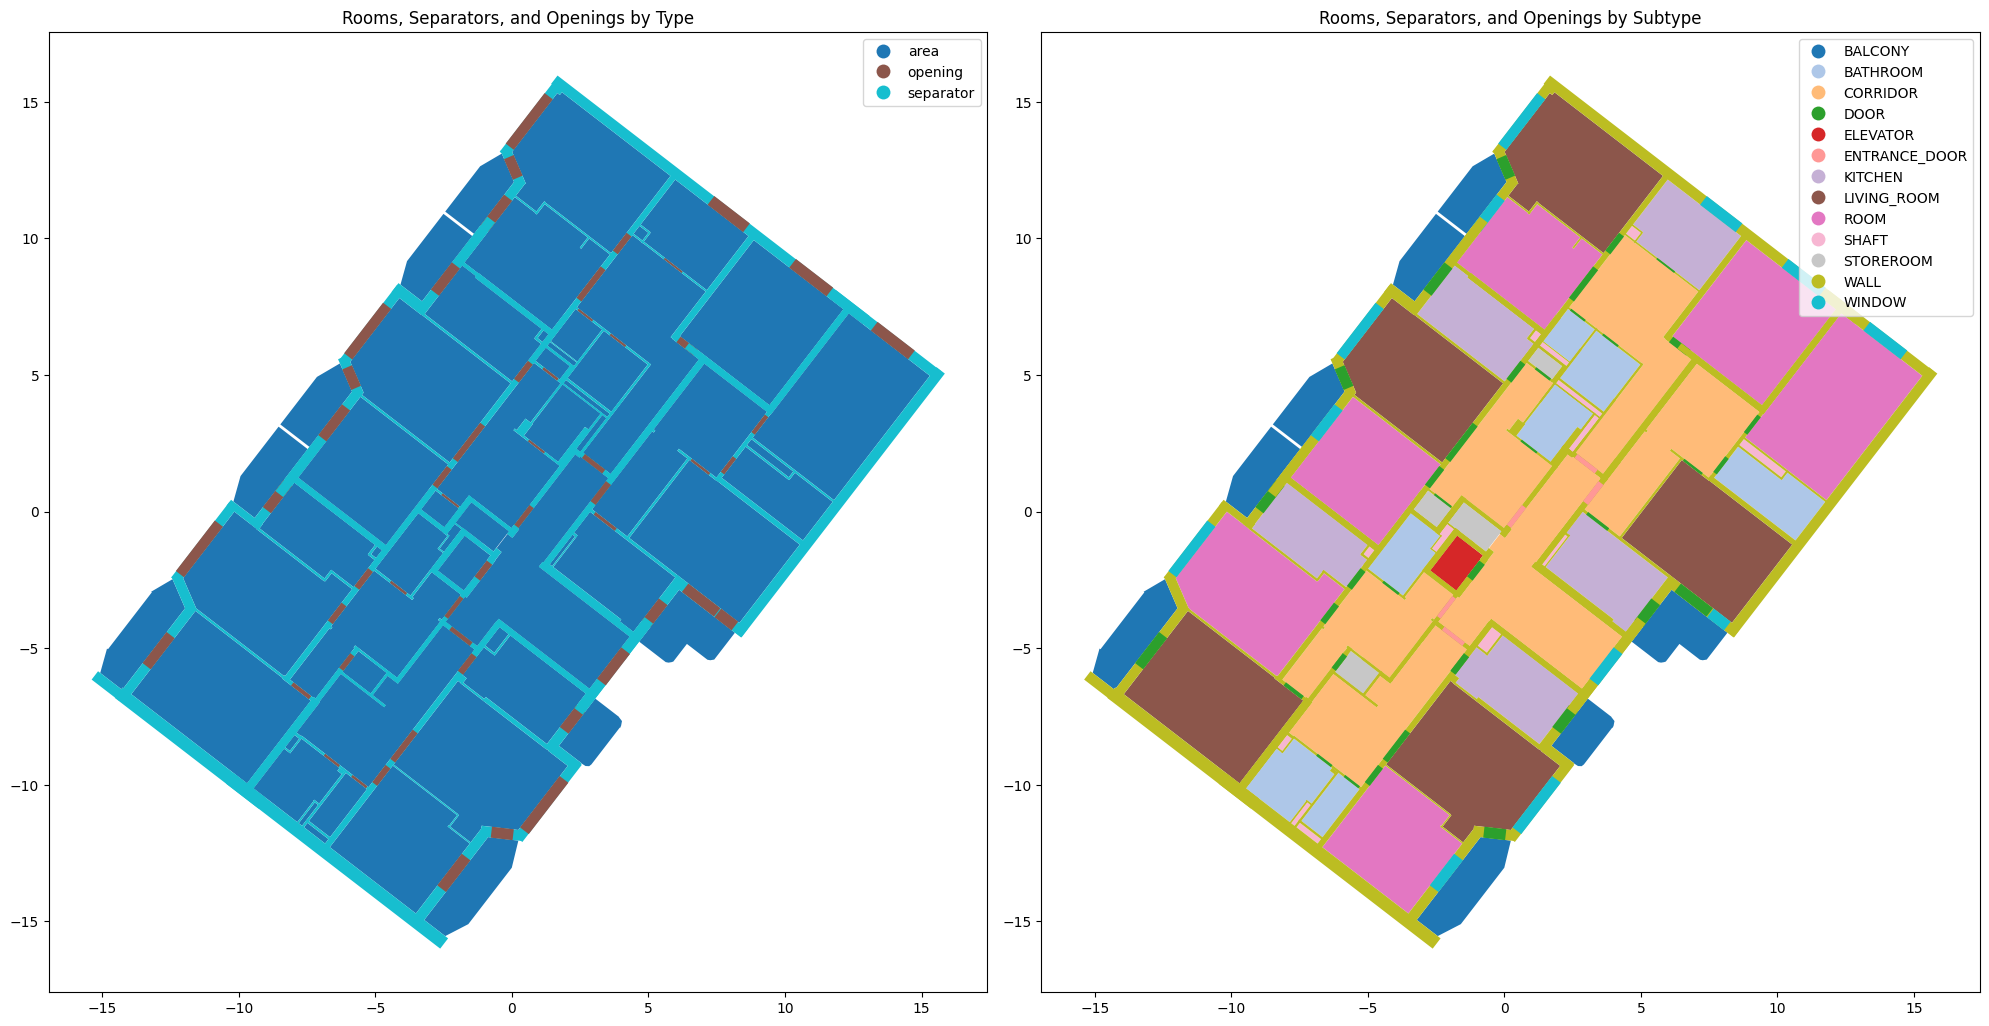

In [97]:
import plot as pl

# Plot geom of rooms, separators and openings in the same plot
floor_DF = DF[DF.floor_id == floor_ids[1]]
floor_DF['geom'] = floor_DF['geom'].apply(wkt.loads)  # Convert WKT strings to Shapely geometry objects
floor_DF = floor_DF.set_geometry('geom')

pl.plot_DF_geometries(floor_DF)

To get an idea of the information within the dataframe, let's show the top (`.head`) of it.
Note that many of the columns from the *Swiss Dwellings* dataset ($\longrightarrow$ [Swiss Dwellings](https://zenodo.org/records/7788422)) are removed, to reduce clutter.

In [98]:
DF.head(10)  # By default, head shows 5. Let's do a bit more, say 10.

,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom
1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom
2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom
3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen
4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom
5,5,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619314.0,RESIDENTIAL,area,BALCONY,POLYGON ((6.6332818443542809 1.893154628642479...,0.0,2.6,Zone4,Balcony
6,6,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619315.0,RESIDENTIAL,area,CORRIDOR,POLYGON ((-0.8407103586364295 2.49132970436546...,0.0,2.6,Zone2,Corridor
7,7,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,NaN,RESIDENTIAL,separator,WALL,POLYGON ((10.1119554317056775 4.97986505334461...,0.0,2.6,Structure,Structure
8,8,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,NaN,RESIDENTIAL,separator,WALL,POLYGON ((-1.1111620360693770 4.87501963298749...,0.0,2.6,Structure,Structure
9,9,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,NaN,RESIDENTIAL,separator,WALL,POLYGON ((3.9249330187591767 -1.31971700237801...,0.0,2.6,Structure,Structure


Each element in the dataframe is an architectural element, and has a corresponding geometry (`geom`), which is a represented by polygon.
Each element is located in:

- a particular site (accessed by the column `site_id`);
- a building (`building_id`);
- a floor (`floor_id)`; and
- an apartment (`apartment_id')`.

(We leave `plan_id`, `unit_id`, and `area_id` for what they are now. I.e.: we do not need them here.)

Before we extract the geometries, let's get an idea of the separator, opening, and room types:

In [99]:
# Show types of separators
print(list(DF[DF.entity_type == 'separator'].entity_subtype.unique()))

# Show types of openings
print(list(DF[DF.entity_type == 'opening'].entity_subtype.unique()))

# Show room types
print(list(DF.roomtype.unique()))

['WALL', 'COLUMN']
['DOOR', 'WINDOW', 'ENTRANCE_DOOR']
['Bathroom', 'Livingroom', 'Bedroom', 'Kitchen', 'Balcony', 'Corridor', 'Structure', 'Door', 'Window', 'Entrance Door', 'Dining', 'Stairs', 'Storeroom']


Note that we will only need the `roomtype` column for all the information that we want as doors, entrance doors, and windows are already included as distinct categories already.

### Extracting geometries

Let's get the geometries associated with the walls and columns (1), doors (2), entrance doors (3), and windows (4).
We will do so for one floor (randomly sampled from the list of floor IDs in `floor_id`)

In [100]:
from shapely import wkt
def get_geometries_from_id(df, floor_id, apartment_id=None, column='roomtype'):
    """Function that extracts all geometries, associated categories, elevations, and heights
    from a particular floor and apartment ID. Outputs a list of geometries (1), a corresponding
    list of categories (2), a list of elevations (3), and a list of heights (4)."""

    # Samples dataframe based on floor and, if asked for, apartment ID
    df_floor = df[df.floor_id == floor_id].reset_index(drop=True)
    if apartment_id is not None:
        df_floor = df_floor[df_floor.apartment_id == apartment_id].reset_index(drop=True)
    else:
        pass
    df_floor.geom = df_floor.geom.apply(wkt.loads)

    # Get geometries, associated categories, elevations, and heights
    geoms, cats, elevations, heights = zip(*df_floor[["geom", column, "elevation", "height"]].values)

    return geoms, cats, elevations, heights


In [101]:
# Gets list of floor IDs and samples one (at 0)
floor_ids = list(DF.floor_id.dropna().unique())
floor_id = floor_ids[1]

# Gets list of apartment IDs within the given floor
apartment_ids = list(DF[DF.floor_id == floor_id].apartment_id.dropna().unique())

# Gets geometries and associated categories
geoms, cats, elevations, heights = get_geometries_from_id(DF, floor_id)

walls = [geom for geom, type in zip(geoms, cats) if type == 'Structure']  # (1) Walls and columns
doors = [geom for geom, type in zip(geoms, cats) if type == 'Door']  # (2) Doors
entrances = [geom for geom, type in zip(geoms, cats) if type == 'Entrance Door']  # (3) Entrance doors
windows = [geom for geom, type in zip(geoms, cats) if type == 'Window']  # (4) Windows

print(f"Number of apartments:\t\t\t{len(apartment_ids)}\n"
        f"Number of structural elements:\t{len(walls)}\n"
        f"Number of doors:\t\t\t\t{len(doors)}\n"
        f"Number of entrances:\t\t\t{len(entrances)}\n"
        f"Number of windows:\t\t\t{len(windows)}")

Number of apartments:			5
Number of structural elements:	192
Number of doors:				38
Number of entrances:			13
Number of windows:			12


Let's plot the elements in one figure:

In [102]:
def plot_polygon(ax, poly, label=None, **kwargs):
    """Plots a polygon by filling it up. Edges of shapes are avoided to show exactly the area that
    the elements occupy."""
    x, y = poly.exterior.xy
    ax.fill(x, y, label=label, **kwargs)
    return

def draw_walls_and_openings(ax, geoms, cats, colors, **kwargs):
    """Draws the walls and openings of a floor layout."""

    # Extracts walls and columns (1), doors (2), entrances (3), and windows (4)
    walls = [geom for geom, type in zip(geoms, cats) if type == 'Structure']  # (1) Walls and columns
    doors = [geom for geom, type in zip(geoms, cats) if type == 'Door']  # (2) Doors
    entrances = [geom for geom, type in zip(geoms, cats) if type == 'Entrance Door']  # (3) Entrance doors
    windows = [geom for geom, type in zip(geoms, cats) if type == 'Window']  # (4) Windows

    # Plot geometries
    # Draws walls first; doors and windows 'overwrite' the walls. (Makes more sense.)
    _ = [plot_polygon(ax, geom, facecolor=colors[0]) for geom in walls]
    _ = [plot_polygon(ax, geom, facecolor=colors[1]) for geom in doors]
    _ = [plot_polygon(ax, geom, facecolor=colors[2]) for geom in entrances]
    _ = [plot_polygon(ax, geom, facecolor=colors[3]) for geom in windows]

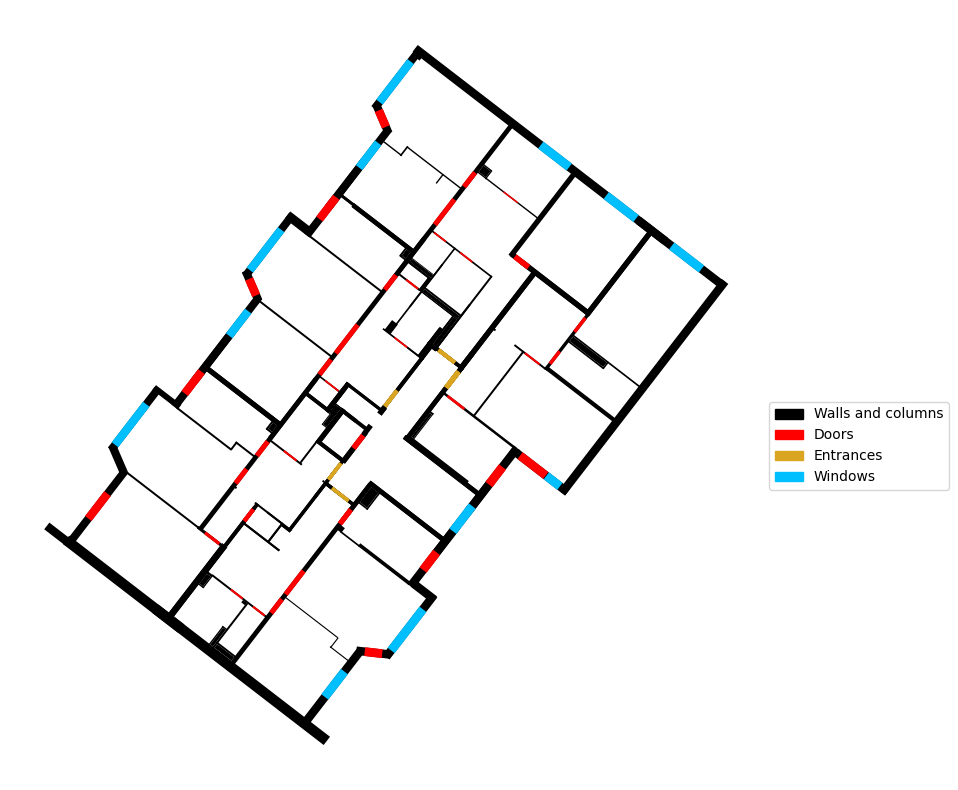

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set figure and specs
fs = 10
fig, ax = plt.subplots(1, 1, figsize=(fs, fs))
ax.set_aspect('equal')
ax.axis('off')

# Color palette and naming
sep_colors = ["black", "red", "goldenrod", "deepskyblue"]
sep_names = ["Walls and columns", "Doors", "Entrances", "Windows"]

# Plot geometries
draw_walls_and_openings(ax, geoms, cats, sep_colors)

# Create legend (left middle outside)
patches = [mpatches.Patch(color=color, label=label) for color, label in zip(sep_colors, sep_names)]
_ = plt.legend(handles=patches, loc='upper left', bbox_to_anchor=(1, 0.5), fontsize=fs)

That looks good.
We can do the same for all individual apartments on this floor.
Remember: for the floor plan above, there are 5 apartments.

In [104]:
# Gets list of floor IDs and samples one (at 0)
floor_ids = list(DF.floor_id.dropna().unique())
floor_id = floor_ids[1]

# Gets list of apartment IDs within the given floor
apartment_ids = list(DF[DF.floor_id == floor_id].apartment_id.dropna().unique())

# Gets geometries and associated categories
geoms, cats, elevations, heights = get_geometries_from_id(DF, floor_id)

# Get geometries and categories for each apartment ID
apartments = []
for apartment_id in apartment_ids:
    geoms, cats, elevations, heights = get_geometries_from_id(DF, floor_id, apartment_id=apartment_id)
    apartments.append([geoms, cats, elevations, heights])

print(len(apartments))

5


Indeed the lenght of `apartments` corresponds with the number of apartments within the overall floor plan.

Let's plot them individually.
We draw them in different subplots.
And using `unary_union` from `shapely` we construct the boundary of the overall floor plan and plot it underneath the apartments in gray.

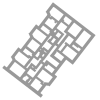

In [105]:
import numpy as np
from shapely.ops import unary_union

# Get tightest boundary of floor plan
# First: load all geometries that are walls or columns
# Second: Unite all these geometries using the union of them
# Third: Find the polygon within the union that is largest in terms of area (using np.argsort)
# and choose the largest (which is by default put on the end of the sort)
geoms, cats, elevations, heights  = get_geometries_from_id(DF, floor_id)
structure = unary_union([geom for geom, cat in zip(geoms, cats) if cat == 'Structure'])
boundary = structure.geoms[np.argsort([geom.area for geom in structure.geoms])[-1]]

# Check whether the boundary / polygon makes sense
# (When a shapely Polygon object is called, the shape is directly visualized in the output.)
boundary

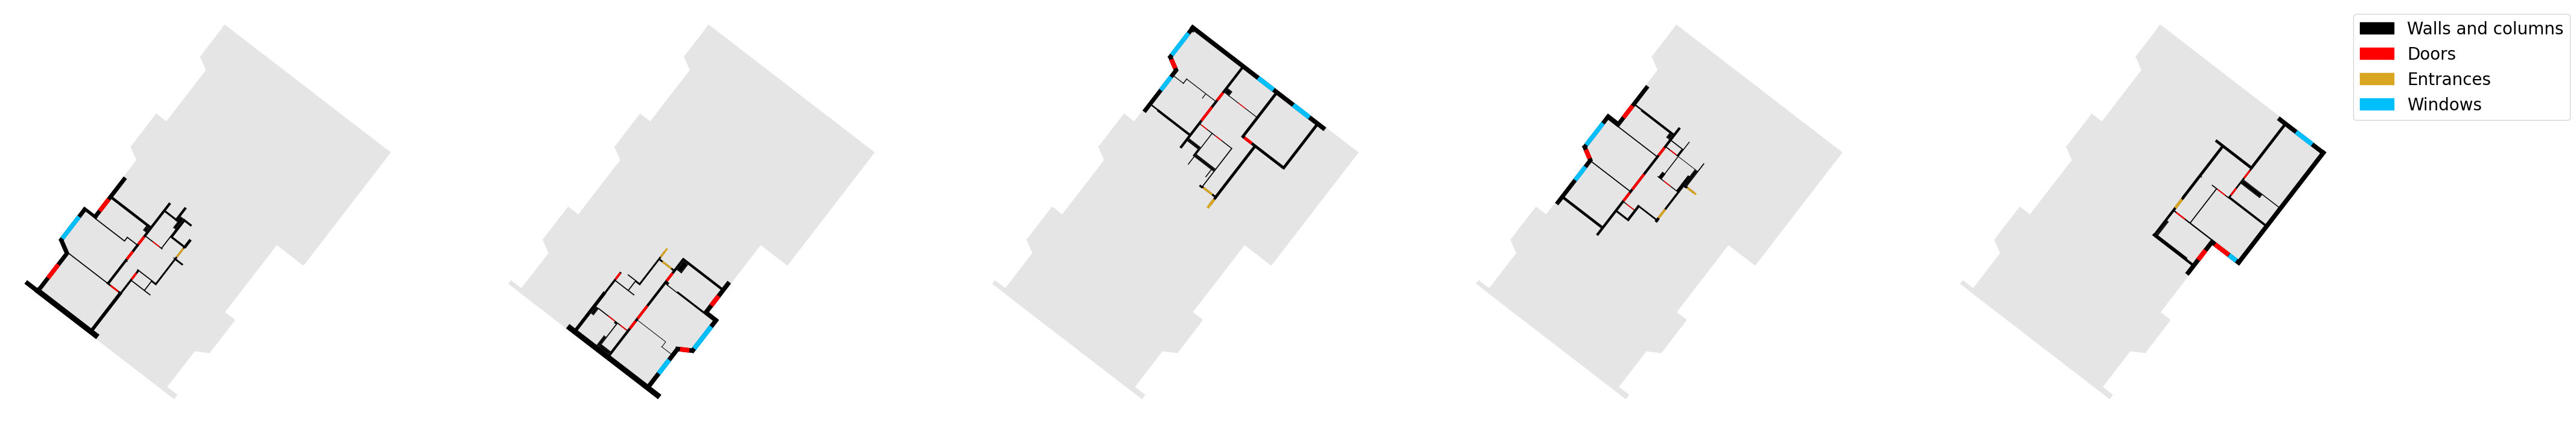

In [106]:
# Set figure and specs
fs = 10
nc = len(apartments)  # Number of columns
fig, axs = plt.subplots(1, nc, figsize=(fs*nc, fs))
axs = axs.flatten()

# Loop through apartments
for ax, (geoms, cats, elevations, heights) in zip(axs, apartments):

    # Set axis
    ax.set_aspect('equal')
    ax.axis('off')

    # Plot structure of the whole building
    plot_polygon(ax, boundary, facecolor="gray", alpha=0.2)

    # Plot geometries
    draw_walls_and_openings(ax, geoms, cats, sep_colors)

# Create legend (left middle outside)
patches = [mpatches.Patch(color=color, label=label) for color, label in zip(sep_colors, sep_names)]
_ = plt.legend(handles=patches, loc='upper left', bbox_to_anchor=(1, 1), fontsize=fs*2)

You can clearly see that the floor plan is cut into the individual apartments out of which it is composed.

In the next couple of code blocks we will show the spaces as well.

In [107]:
room_names = ['Bedroom', 'Livingroom', 'Kitchen', 'Dining', 'Corridor', 'Stairs', 'Storeroom', 'Bathroom', 'Balcony', 'Other']
room_colors = ['#1f77b4',   # bedroom
               '#e6550d',   # living room
               '#fd8d3c',   # kitchen
               '#fdae6b',   # dining
               '#fdd0a2',   # corridor
               '#72246c',   # stairs
               '#5254a3',   # storeroom
               '#6b6ecf',   # bathroom
               '#2ca02c',   # balcony
               '#8c564b']   # other


def draw_rooms(ax, geoms, cats, room_colors, room_names):
    """Draws the rooms of the floor plan layout."""

    # Simultaneously extract geometries and categories
    # And directly plot them int the correct color
    for geom, cat in zip(geoms, cats):
        if cat in room_names:
            plot_polygon(ax, geom, facecolor=room_colors[room_names.index(cat)])

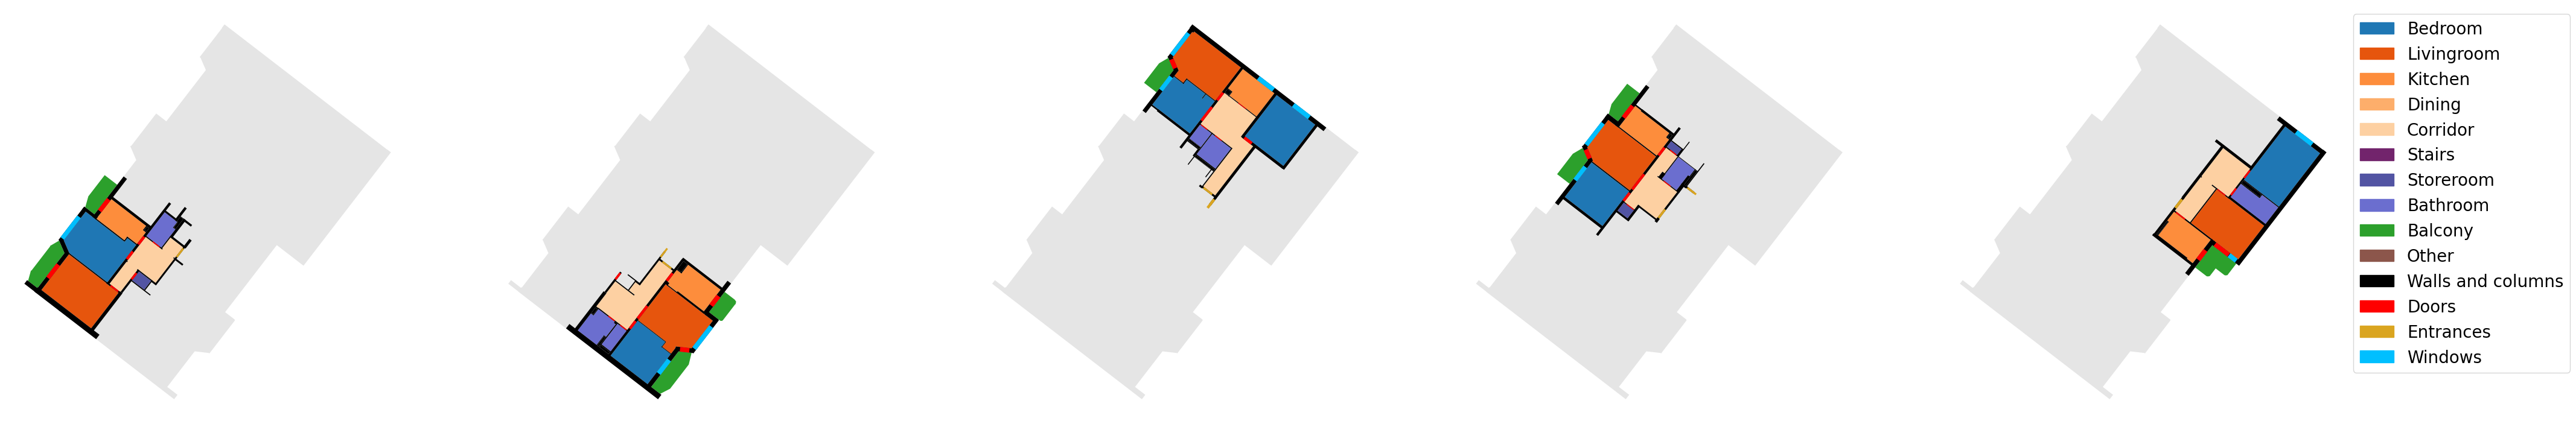

In [108]:
# Set figure and specs
fs = 10
nc = len(apartments)  # Number of columns
fig, axs = plt.subplots(1, nc, figsize=(fs*nc, fs))
axs = axs.flatten()

# Loop through apartments
for ax, (geoms, cats, elevations, heights) in zip(axs, apartments):

    # Set axis
    ax.set_aspect('equal')
    ax.axis('off')

    # Plot structure of the whole building
    plot_polygon(ax, boundary, facecolor="gray", alpha=0.2)

    # Plot geometries
    draw_rooms(ax, geoms, cats, room_colors, room_names)
    draw_walls_and_openings(ax, geoms, cats, sep_colors)

# Create legend (left middle outside)
colors = room_colors + sep_colors
names = room_names + sep_names
patches = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, names)]
_ = plt.legend(handles=patches, loc='upper left', bbox_to_anchor=(1, 1), fontsize=fs*2)

### Extracting graphs

Now it is time to extract the graphs.
We do this per individual apartment.
For now, we will not bother about the entrances and the windows, and completely focus on the layout of the apartment as if it would be isolated from the rest of the world.

As mentioned before, the graph extraction algorithm is slightly different from our previous implemention ($\longrightarrow$ [Data Curation Part 2 - Graph Extraction](https://github.com/caspervanengelenburg/msd/blob/main/NB%20-%20Data%20Curation%202%20-%20Graph%20Extraction.ipynb)):
We include more features / attributes to the nodes, edges, and the graph itself (1) and the room categorization is slightly modified (2).
The format of the data stays the same; so, if you already worked with the other graph data, it won't be difficult to modify your code to work with the ones we'll extract here.

Graphs are stored as `nx.Graph()` data structures, which IMHO is one of the easiest-to-work-with graph containers you can find in Python.

The graph extraction algorithm below should be self-explainable from the comments.

One thing to highlight here (which is quite different from our earlier algorithm) is to way to check the connectivity by doors.
The door geometries are temporarily modified by rotating them 90 degrees and making them slightly smaller.
This means that there is more clearly overlap between the rotated door geometry and the two rooms that the door connects.
This makes the algorithm more robust to slightly misplaced doors.


In [113]:
from warnings import catch_warnings
from copy import deepcopy
from itertools import combinations
import torch
import networkx as nx
from shapely.geometry import Polygon
from shapely.affinity import rotate, scale
import graphs as gr
import utils as ut

def rotate_rectangle(rect: Polygon, scale_factor=0.5, angle=90):
    # Compute centroid (center point)
    centroid = rect.centroid

    # Scale the rectangle (relative to the centroid)
    scaled_rect = scale(rect, xfact=scale_factor, yfact=scale_factor, origin=centroid)

    # Rotate the scaled rectangle around its center
    rotated_rect = rotate(scaled_rect, angle, origin=centroid)

    return rotated_rect

def polygon_to_list(polygon: Polygon) -> list:
    """Converts a polygon into a list of coordinates."""
    return list(zip(*polygon.exterior.coords.xy))

def extract_access_graph(geoms, cats, elevations, heights, names, apartment_id, floor_id):
    """Extracts the access graph from a set of apartment."""

    # Defines the graph
    G = nx.Graph()

    # Sets the mapping
    mapping_names = {cat: i for i, cat in enumerate(names)}

    # Initializes empty lists for rooms and their categories, doors, and walls
    rooms, room_cats, doors, entrances, walls, windows = [], [], [], [], [], []
    room_z, doors_z, entrances_z, walls_z, windows_z = [], [], [], [], []

    # Loops through the geometries and corresponding categories
    for geom, cat, height in zip(geoms, cats, heights):

        # Add z-coordinate to the geometry
        z_coord = height / 2

        if cat == 'Door':  # Doors
            doors.append(geom)
            doors_z.append(z_coord)
        elif cat == 'Entrance Door':  # Entrances
            doors.append(geom)
            doors_z.append(z_coord)
            entrances.append(geom)
            entrances_z.append(z_coord)
        elif cat in names[:9]:  # Rooms
            rooms.append(geom)
            room_z.append(z_coord)
            room_cats.append(cat)
        elif cat == 'Structure':  # Walls and columns
            walls.append(geom)
            walls_z.append(z_coord)
        elif cat == 'Window':  # Windows
            windows.append(geom)
            windows_z.append(z_coord)
        else:
            continue


    for key, (room, cat, z) in enumerate(zip(rooms, room_cats, room_z)):
        # for each room in the apartment

        # create dict for room, cat, and z
        room_dict = {
            'geom': room,
            'entity_subtype': cat,
            'category': mapping_names[cat],
            'z': z
        }

        # search for intersections with openings
        wall_indexes, door_indexes, window_indexes = ut.find_intersections(room, walls, doors, windows)

        gr.add_room_geometries(room_dict, floor_id, apartment_id, key, G)

        gr.add_opening_geometry(doors, windows, door_indexes, window_indexes, doors_z, windows_z, room_dict, floor_id, apartment_id, key, G)
            
    gr.connect_area_by_openings(G, str(str(floor_id) + "_" + str(apartment_id)))

    # Graph attributes / features
    G.graph["Floor ID"] = floor_id  # Floor ID
    G.graph["Apt ID"] = apartment_id  # Apartment ID (i.e., name)
    G.graph["Structure"] = walls  # Walls and columns
    G.graph["Windows"] = windows  # Windows
    G.graph["Entrances"] = entrances  # Entrances (doors)
    
    return G


Let's load the graphs in a list called `graphs`:

In [116]:
from IPython.display import clear_output
#force reimport of graphs
import importlib

import utils as ut
importlib.reload(ut)
import graphs as gr
importlib.reload(gr)

# Import necessary modules
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Initialize emtpy list for graphs
graphs = []

# Loop over apartments
for i, ((geoms, cats, elevations, heights), apartment_id) in enumerate(zip(apartments, apartment_ids)):
    clear_output(wait=True)
    print(f"Graphs extracted: {i+1} / {len(apartments)}")
    G = extract_access_graph(geoms, cats, elevations, heights, names, apartment_id, floor_id)
    graphs.append(G)


Graphs extracted: 5 / 5
Opening IDs: ['door_6', 'door_5', 'door_0', 'door_4', 'door_3', 'door_1', 'door_2']
Connected areas for opening door_6: ['Balcony_3', 'Kitchen_4']
Connected areas for opening door_5: ['Bathroom_1', 'Corridor_2']
Connected areas for opening door_0: ['Livingroom_0', 'Corridor_2']
Connected areas for opening door_4: ['Livingroom_0', 'Balcony_3']
Connected areas for opening door_3: ['Corridor_2', 'Kitchen_4']
Connected areas for opening door_1: ['Corridor_2']
Connected areas for opening door_2: ['Corridor_2', 'Bedroom_5']
Opening IDs: ['window_1', 'window_0']
Connected areas for opening window_1: ['Livingroom_0', 'Balcony_3']
Connected areas for opening window_0: ['Bedroom_5']


In [115]:
print("Nodes:")
for node, data in graphs[0].nodes(data=True):
    print(f"{node}: {data}")
print("\nEdges:")
for u, v, data in graphs[0].edges(data=True):
    print(f"{u} -- {v}: {data}")

Nodes:
9706_a5266a0d0a3628c0d381f64a9b5aa977_Corridor_0_centroid: {'polygon': [(-6.67999181995738, -4.276634286866225), (-6.629153424215943, -4.315810540007282), (-6.573085882358273, -4.243052589650301), (-6.62392427809971, -4.203876336509243), (-5.050259689289356, -2.16175702402251), (-3.6471199668257386, -3.243021610715715), (-3.59105242496807, -3.170263660358735), (-3.641890820709503, -3.1310874072176773), (-2.937939051630643, -2.217580480190815), (-1.8617492582311845, -3.046896259321059), (-2.5657010273100447, -3.960403186347925), (-2.6470424604963423, -3.8977211813222326), (-2.703110002354011, -3.9704791316792125), (-2.6217685691677133, -4.033161136704907), (-4.203268408606279, -6.085448128339927), (-5.73858795999763, -4.902325283479968), (-5.794655501855299, -4.9750832338369495), (-5.764152464410438, -4.998588985721586), (-7.188947291284769, -6.847522394390861), (-7.260121045322778, -6.79267563999338), (-7.275791546579202, -6.813010998289954), (-8.128292398716347, -6.156070732980

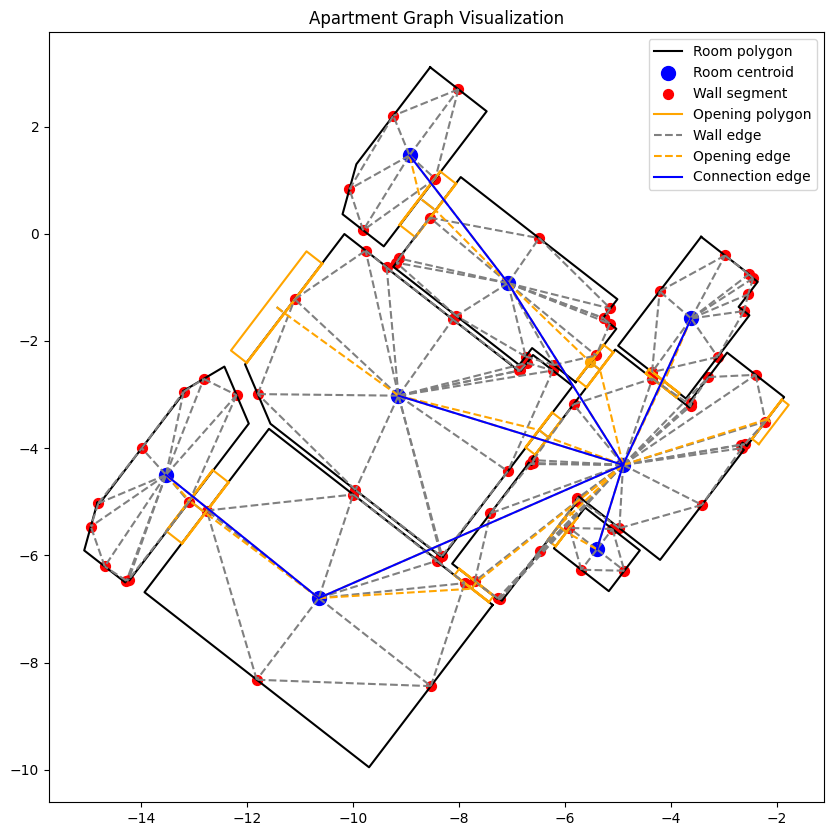

In [119]:
def plot_a_graph(graphs_list, viz_rooms=True, viz_walls=True, viz_openings=False, viz_room_connection=True, viz_normals=False):
    """
    Visualizes geometries, wall segments, and graph edges for multiple apartments in 2D.

    Parameters:
    graphs_list (list of networkx.Graph): List of graphs with nodes ('type', 'center', 'normal') and edges for the apartments.
    viz_normals (bool): If True, plots wall segment normals.
    viz_rooms (bool): If True, displays room polygons.
    viz_walls (bool): If True, displays wall segments.
    viz_openings (bool): If True, displays openings (doors and windows).
    viz_wall_edges (bool): If True, displays edges between wall segments.
    viz_connection_edges (bool): If True, displays edges connecting rooms via openings.

    """
    _, ax = plt.subplots(1, 1, figsize=(10, 10))
    legend_added = False  # Flag to ensure the legend is added only once
    normal_added = False  # Flag to ensure the "Normal" label is added only once

    for graphs in graphs_list:
        # Visualize room polygons
        if viz_rooms:
            room_nodes = [n for n, d in graphs.nodes(data=True) if d['type'] == 'room']
            for idx, room_node in enumerate(room_nodes):
                room_data = graphs.nodes[room_node]
                room_polygon = Polygon(room_data['polygon'])
                x, y = room_polygon.exterior.xy
                ax.plot(x, y, color='black', label='Room polygon' if not legend_added and idx == 0 else "")

            # Draw room centroids
            for idx, room_node in enumerate(room_nodes):
                room_data = graphs.nodes[room_node]
                ax.scatter(room_data['center'][0], room_data['center'][1], color='blue', s=100, label='Room centroid' if not legend_added and idx == 0 else "")

        # Visualize wall segments
        if viz_walls:
            wall_nodes = [n for n, d in graphs.nodes(data=True) if d['type'] == 'ws']
            for idx, wn in enumerate(wall_nodes):
                wall_data = graphs.nodes[wn]
                ax.scatter(wall_data['center'][0], wall_data['center'][1], color='red', s=50, label='Wall segment' if not legend_added and idx == 0 else "")
                if viz_normals:
                    ax.arrow(wall_data['center'][0], wall_data['center'][1],
                             wall_data['normal'][0], wall_data['normal'][1],
                             head_width=0.1, head_length=0.1, fc='green', ec='green', label='Normal' if not normal_added else "")
                    normal_added = True
        # Visualize openings
        if viz_openings:
            opening_nodes = [n for n, d in graphs.nodes(data=True) if 'door' in d['type'] or 'window' in d['type']]
            for idx, on in enumerate(opening_nodes):
                opening_data = graphs.nodes[on]
                opening_polygon = Polygon(opening_data['polygon'])
                x, y = opening_polygon.exterior.xy
                ax.plot(x, y, color='orange', label='Opening polygon' if not legend_added and idx == 0 else "")

            # Draw opening centroids
            ax.scatter(opening_data['center'][0], opening_data['center'][1], color='orange', s=50, label='Opening centroid' if not legend_added and idx == 0 else "")
            if viz_normals:
                ax.arrow(opening_data['center'][0], opening_data['center'][1],
                    opening_data['normal'][0], opening_data['normal'][1],
                    head_width=0.1, head_length=0.1, fc='green', ec='green', label='Normal' if not normal_added else "")
                normal_added = True

        # Visualize wall edges
        if viz_walls:
            wall_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'ws' in d['type']]
            for idx, edge in enumerate(wall_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                    [start_node['center'][1], end_node['center'][1]],
                    color='gray', linestyle='--', label='Wall edge' if not legend_added and idx == 0 else "")
                
        #vizualize opening edges
        if viz_openings:
            wall_edges = [(u, v) for u, v, d in graphs.edges(data=True)  if 'door' in d['type'] or 'window' in d['type']]
            for idx, edge in enumerate(wall_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                    [start_node['center'][1], end_node['center'][1]],
                    color='orange', linestyle='--', label='Opening edge' if not legend_added and idx == 0 else "")

        # Visualize connection edges
        if viz_room_connection:
            connection_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'connected' in d['type']]
            for idx, edge in enumerate(connection_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                        [start_node['center'][1], end_node['center'][1]],
                        color='blue', linestyle='-', label='Connection edge' if not legend_added and idx == 0 else "")

        legend_added = True  # Set the flag to True after processing the first graph

    plt.title("Apartment Graph Visualization")
    plt.legend()
    plt.show()

plot_graphs = [graphs[0]]
plot_a_graph(plot_graphs,viz_openings=True, viz_room_connection=True, viz_normals=False)

Now, we can loop over all floor and extract the apartment graphs from them.

In [140]:
# Compute number of apartments
N_apartments = 0
for floor_id in floor_ids:
    N_apartments += DF[DF.floor_id == floor_id].apartment_id.dropna().nunique()

print(f"Number of apartments:\t{N_apartments}")

Number of apartments:	20528


It takes quite a while to extract all the graphs.
You can also do it for the first 50 floor plans to check the code, like we do in the following block:

In [139]:
graphs = []

for floor_id in floor_ids[:20]:

    # Get apartment IDs within the floor
    apartment_ids = list(DF[DF.floor_id == floor_id].apartment_id.dropna().unique())

    # Loop over the apartments and extract the graphs
    for apartment_id in apartment_ids:
        geoms, cats, elevations, heights = get_geometries_from_id(DF, floor_id, apartment_id=apartment_id)
        G = extract_access_graph(geoms, cats, elevations, heights, names, apartment_id, floor_id)
        graphs.append(G)

    clear_output(wait=True)
    print(f"Apartments done: {len(graphs)} / {N_apartments}")

Apartments done: 67 / 20528


In [141]:
import pickle

def save_pickle(object, filename):
    """Saves a pickled file."""
    with open(filename, 'wb') as f:
        pickle.dump(object, f)
    f.close()

# Saves graphs
# save_pickle(graphs, '/content/drive/MyDrive/Colab Notebooks/Data/MSD Dump/MSD - Some Apartment-Level Graphs.pickle')
save_pickle(graphs, 'data/MSD - Some Apartment-Level Graphs.pickle')

## (2) Filtering

This section is about removing apartment layouts that are either nearly similar to others (1) are not very informative (e.g., the upper part of an apartment that might only have 1 bedroom) (2).
Why (1)? Too many very similar layouts will slow down and likely bias training.
Why (2)? Good question ...

### Counting storeys in an apartment

Some apartments live at multiple storeys in a building.

Let's plot the histogram of the number of storeys apartments have.
This is easily extracted from the dataframe by counting the number of unique floor IDs can be found when the dataframe is filtered on a particular apartment ID.

In [142]:
# Get apartment IDs
apartment_ids = list(DF.apartment_id.dropna().unique())
print(len(apartment_ids))

# Get unit IDs (Should be more!)
unit_ids = list(DF.unit_id.dropna().unique())
print(len(unit_ids))

19638
20542


In [143]:
# Get storeys per apartment dataframe
storeys_per_apartment = DF.groupby('apartment_id')['floor_id'].nunique()

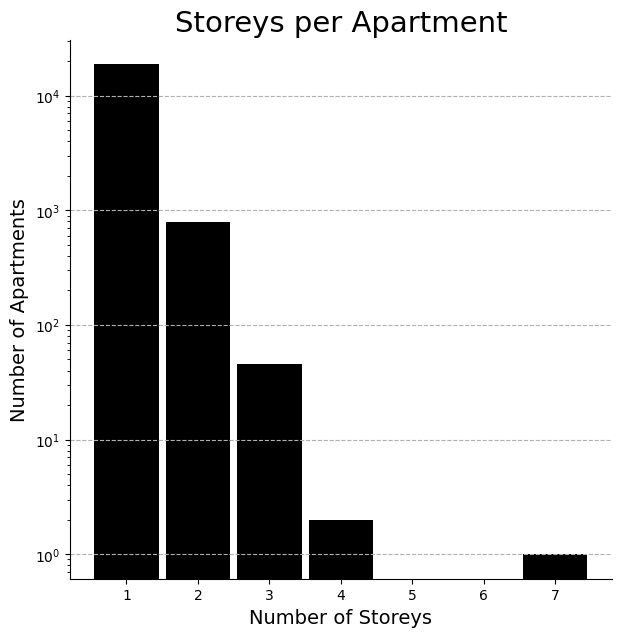

In [144]:
# Set figure
fs = 7
fig, ax = plt.subplots(1, 1, figsize=(fs, fs))

# Histogram
ax.hist(storeys_per_apartment, bins=range(1, storeys_per_apartment.max() + 2), color='black', align='left', log=True, rwidth=0.9)

# Set labels
ax.set_xlabel('Number of Storeys', fontsize=fs*2)
ax.set_ylabel('Number of Apartments', fontsize=fs*2)
_ = ax.set_title('Storeys per Apartment', fontsize=fs*3)

# Set axes
ax.grid(axis='y', linestyle='--', alpha=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

Since there are only a few apartments covering multiple storeys, we simply don't consider these apartments.

In [145]:
single_apartment_ids = storeys_per_apartment[storeys_per_apartment == 1].index.tolist()
print(len(single_apartment_ids))

18803


### Extracting all single-storey apartment graphs

In the next cell, we will convert all the (single-storey) apartments to information-rich graphs and put them together in a list.
This procedure takes quite some time (~30 min, depending on your machine / server).
Make sure to save it afterwards: Loading the list of graphs from your folder takes way less time than repeating the extraction.

In [147]:
graphs = []

for floor_id in floor_ids:

    # Get apartment IDs within the floor
    apartment_ids = list(DF[DF.floor_id == floor_id].apartment_id.dropna().unique())
     # Remove those that are covering more than 1 storey (by set intersection)
    apartment_ids = list(set(apartment_ids).intersection(set(single_apartment_ids)))

    # Loop over the apartments and extract the graphs
    for apartment_id in apartment_ids:
        geoms, cats, elevations, heights = get_geometries_from_id(DF, floor_id, apartment_id=apartment_id)
        G = extract_access_graph(geoms, cats, elevations, heights, names, apartment_id, floor_id)
        graphs.append(G)

    clear_output(wait=True)
    print(f"Apartments done: {len(graphs)} / {len(single_apartment_ids)}")

Apartments done: 207 / 18803


KeyboardInterrupt: 

Again: don't forget to save them.
Note that it's about 150MB only!

In [ ]:
# Saves graphs
save_pickle(graphs, f'/content/drive/MyDrive/Colab Notebooks/Data/MSD Dump/MSD - Apartment-Level Graphs {len(graphs)/1000:.1f}K.pickle')

Load the graphs

In [ ]:
def load_pickle(filename):
    """
    Loads a pickled file.
    """
    with open(filename, 'rb') as f:
        object = pickle.load(f)
        f.close()
    return object

In [ ]:
graphs = load_pickle('/content/drive/MyDrive/Colab Notebooks/Data/MSD Dump/MSD - Apartment-Level Graphs 18.8K.pickle')

Let's visualize a couple of them:

In [ ]:
import random

# Set figure and specs
fs = 10
nc, nr = 15, 15
fig, axs = plt.subplots(nr, nc, figsize=(fs*nc, fs*nr))
axs = axs.flatten()

# Set coloring of graph
node_color = edge_color = "black"

# Loop through apartments (pick at random)
random.seed(42)
for ax, G in zip(axs, random.sample(graphs, k=nc*nr)):

    # Set axis
    ax.set_aspect('equal')
    ax.axis('off')

    # Plot floor plan + graph
    draw_floor_from_graph(G, ax, s=fs*4, w=fs/3,
                          node_color=node_color,
                          edge_color=edge_color,
                          viz_walls=False,
                          viz_entrances=False)

    # Put title (floor and apt ID)
    # ax.set_title(f"F {G.graph['Floor ID']}", fontsize=fs*6)

While many of the floor plans are great, there are many that are not really informative, such as:

- Floor plans that consist of a few number of rooms (some are only bedrooms ...)
- Floor plans without a living room. Reconsidered: We keep them in, there are many apartments without it.

Let's check the sizes (in terms of amount of rooms) of the apartments (1) and number of apartments with a living room more closely (2).

In [ ]:
from tqdm.auto import tqdm

N_rooms = []
N_with_living = 0

for G in tqdm(graphs):
    N_rooms.append(G.number_of_nodes())  # (1)
    # Checks presence of living room among the nodes
    N_with_living += 1 if 1 not in [d for _, d in G.nodes(data="category")] else 0  # (2)

In [ ]:
# Print number of apartments that have a living room
print(N_with_living)
print(N_rooms[:50])

Check distribution of the apartment sizes (i.e., the amount of rooms) through a histogram.

In [ ]:
# Set figure
fs = 7
fig, ax = plt.subplots(1, 1, figsize=(fs, fs))

# Histogram
ax.hist(N_rooms, bins=range(1, np.max(N_rooms) + 2), color='black', align='left', rwidth=0.7)

# Set labels
ax.set_xlabel('Number of Spaces', fontsize=fs*2)
ax.set_ylabel('Number of Apartments', fontsize=fs*2)
_ = ax.set_title('Number of Spaces per Apartment', fontsize=fs*3)

# Set axes
ax.grid(axis='y', linestyle='--', alpha=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

We keep all apartments that have between 5 and 12 rooms.

In [ ]:
graphs_subset = [G for G in tqdm(graphs) if 5 <= G.number_of_nodes() <= 12]

print(f"Number of apartments with 5-12 rooms: {len(graphs_subset)}")

Some apartment are not fully connected.
Here, we keep all apartments that are connected.

In [ ]:
graphs_subset = [G for G in tqdm(graphs_subset) if nx.is_connected(G)]

print(f"Number of apartments with 5-12 rooms and connected: {len(graphs_subset)}")

So, ultimately, in the final dataset we have 16771 apartment-level floor plan graphs.

In [ ]:
import random

# Set figure and specs
fs = 10
nc, nr = 10, 10
fig, axs = plt.subplots(nr, nc, figsize=(fs*nc, fs*nr))
axs = axs.flatten()

# Set coloring of graph
viz_rooms = True
viz_walls = False
viz_entrances = False
viz_doors = True
viz_windows = True
node_color = edge_color ="black" # other option: fuchsia (pink!)

# Loop through apartments (pick at random)
random.seed(42)
for ax, G in zip(axs, random.sample(graphs_subset, k=nc*nr)):

    # Set axis
    ax.set_aspect('equal')
    ax.axis('off')

    # Plot floor plan + graph
    draw_floor_from_graph(G, ax, s=fs*4, w=fs/3,
                          node_color=node_color,
                          edge_color=edge_color,
                          viz_rooms=viz_rooms,
                          viz_walls=viz_walls,
                          viz_entrances=viz_entrances,
                          viz_doors = viz_doors,
                          viz_windows = viz_windows)

    # Put title (floor and apt ID)
    # ax.set_title(f"F {G.graph['Floor ID']}", fontsize=fs*6)

Let's save this 'cleaned' dataset as well:

In [ ]:
save_pickle(graphs_subset, f'/content/drive/MyDrive/Colab Notebooks/Data/MSD Dump/MSD - Apartment-Level Graphs Cleaned {len(graphs_subset)/1000:.1f}K.pickle')

## (3) Meta-data analysis

This part of the notebook sheds light on the meta-data of the dataset.

We divide it into three categories:

- Numeric
- Semantic
- Geometric
- Topological

### Numeric

First things first.
The next shows the apartment size distribution (as per number of rooms).
We already did this before, but not for the final dataset!

In [ ]:
N_rooms = [G.number_of_nodes() for G in graphs_subset]

N_rooms_dict = {n: N_rooms.count(n) for n in np.sort(list(set(N_rooms)))}

In [ ]:
# Get naming and occurrences for the bars
names = N_rooms_dict.keys()
occurrences = N_rooms_dict.values()

# Set figure
fs = 7
tc = "black"
fig, ax = plt.subplots(1, 1, figsize=(fs, fs))

# Histogram
bars = ax.bar(names, occurrences, color='black')

# Set labels
ax.set_xlabel('Number of rooms', fontsize=fs*3)
ax.set_ylabel('Amount', fontsize=fs*3)
ax.tick_params(axis='both', width=fs/3, labelsize=fs*2)

# Set axes / spines
ax.spines['bottom'].set_color(tc)
ax.spines['left'].set_color(tc)
ax.spines['bottom'].set_linewidth(fs/3)
ax.spines['left'].set_linewidth(fs/3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Hide the y-axis ticks and labels
ax.yaxis.set_ticks([])
ax.yaxis.set_ticklabels([])

# Add scores on top of the bars
for bar, occurrence in zip(bars, occurrences):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{occurrence}', ha='center', va='bottom', fontsize=2.5*fs)

### Semantic

We will extract the **room type distribution** i.e., the total number of rooms per room type across the whole dataset.

In [ ]:
# Set classes (int) based on the room names list
classes = list(range(len(room_names)))

# The following creates a list of categories by looping over all the rooms across all graphs
N_room_types = np.concatenate([np.array([cat for _, cat in G.nodes(data="category")]) for G in graphs_subset]).tolist()

# This creates a dictionary: keys are the room types and the values are the number occurrences
# of that room type in the dataset
N_room_type_dict = {room_names[cat]: N_room_types.count(cat) for cat in classes}

# We sort the dictionary by the count of the rooms
N_room_type_dict = dict(sorted(N_room_type_dict.items(), key=lambda item: item[1], reverse=True))

In [ ]:
# Get naming and occurrences for the bars
names = N_room_type_dict.keys()
occurrences = N_room_type_dict.values()

# Set figure
fs = 7
tc = "black"
fig, ax = plt.subplots(1, 1, figsize=(fs*2, fs))

# Histogram
color = [room_colors[room_names.index(cat)] for cat in names]
bars = ax.bar(names, occurrences, color=color)

# Set labels
ax.set_ylabel('Amount', fontsize=fs*3)
ax.tick_params(axis='both', width=fs/3, labelsize=fs*2)

# Set axes / spines
ax.spines['bottom'].set_color(tc)
ax.spines['left'].set_color(tc)
ax.spines['bottom'].set_linewidth(fs/3)
ax.spines['left'].set_linewidth(fs/3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Hide the y-axis ticks and labels
ax.yaxis.set_ticks([])
ax.yaxis.set_ticklabels([])
_ = plt.xticks(rotation=60)

# Add scores on top of the bars
for bar, occurrence in zip(bars, occurrences):
    p = 100 * occurrence / sum(occurrences)  # Computes percentage
    height = bar.get_height()  # Sets the height of the bar in the plot
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{occurrence}', ha='center', va='bottom', fontsize=2.5*fs)

### Geometric

We will extract the distributions of the following:
- Gross area (in $m^2$)
- Area per room type (in $m^2$)
- Area of a room type w.r.t. gross area (in %)

The **gross area**, or total area of a floor plan is measured in $m^2$, and computed as the sum over all room areas.

In [ ]:
# Aggregate gross areas in a list
gross_areas = [np.sum([Polygon(d).area for _, d in G.nodes('polygon')]) for G in graphs_subset]

In [ ]:
# Set figure
fs = 7
fc = "white"
tc = "black"
fig, ax = plt.subplots(1,1,figsize=(fs*2, fs))

# Create histogram
bars = ax.hist(gross_areas, bins=75, color="black", align='left', rwidth=1)

# Set color
fig.set_facecolor(fc)
ax.set_facecolor(fc)

# Make up spines
ax.spines['bottom'].set_color(tc)
ax.spines['left'].set_color(tc)
ax.spines['bottom'].set_linewidth(fs/5)
ax.spines['left'].set_linewidth(fs/5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make up ticks
ax.tick_params(axis='both', width=fs/5, labelsize=fs*2)

# Set grid
ax.grid(axis='y', linestyle='--', alpha=1)

# Make up labels
_ = ax.set_ylabel("Number of floor plans", fontsize=fs*3)
_ = ax.set_xlabel("Gross area [m2]", fontsize=fs*3)

We will do the same, but for each room type individually.
So, we'll get the **distribution of area per room type** (on average across the whole dataset).

In [ ]:
# Aggregate room areas in a dict (key indicates the room type)
room_areas_dict = {cat: [] for cat in room_names}

# Loop over graphs and nodes
for G in graphs_subset:
    for _, d in G.nodes(data=True):
        # Extract category
        cat = room_names[d["category"]]
        # Append to the right list in the dictionary
        room_areas_dict[cat].append(Polygon(d["polygon"]).area)

First, we create bar plot.
Each bar represents a room type.
We compute the mean and standard deviation of the list of areas (values in the dictionary) for each room type category (keys in the dictionary).

In [ ]:
# Create dictionary with statistics of the distribution (mean and std)
S_room_areas_dict = {cat: [np.mean(areas), np.std(areas)] for cat, areas in room_areas_dict.items()}

# Sort dictionary on mean area size (descending order)
S_room_areas_dict = dict(sorted(S_room_areas_dict.items(), key=lambda item: item[1][0], reverse=True))

In [ ]:
# Get naming and occurrences for the bars
names = S_room_areas_dict.keys()
means = [m for m,_ in S_room_areas_dict.values()]
sigmas = [sig for _, sig in S_room_areas_dict.values()]

# Set figure
fs = 7
tc = "black"
fig, ax = plt.subplots(1, 1, figsize=(fs*2, fs))

# Histogram
colors = [room_colors[room_names.index(cat)] for cat in names]
bars = ax.bar(names, means, color=colors)

# Set labels
ax.set_ylabel('Area [m2] ($\mu \pm \sigma$)', fontsize=fs*3)
ax.tick_params(axis='both', width=fs/3, labelsize=fs*2)

# Set axes / spines
ax.spines['bottom'].set_color(tc)
ax.spines['left'].set_color(tc)
ax.spines['bottom'].set_linewidth(fs/3)
ax.spines['left'].set_linewidth(fs/3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Hide the y-axis ticks and labels
ax.yaxis.set_ticks([])
ax.yaxis.set_ticklabels([])
_ = plt.xticks(rotation=60)

# Add scores on top of the bars
for bar, mean, sig in zip(bars, means, sigmas):
    height = bar.get_height()  # Sets the height of the bar in the plot
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{mean:.1f}$\pm${sig:.1f}', ha='center', va='bottom', fontsize=2.5*fs)

To investigate more of the details of the individual area distributions, we can similarly visualize the distributions of each of them (using histograms like for the gross area).
We color the the histograms accordingly.

In [ ]:
# Set up figure
fs = 10
fc = "white"
tc = "black"
fig, axs = plt.subplots(2, 5, figsize=(fs*5, fs*2))
axs = axs.flatten()

for ax, cat, color in zip(axs, names, colors):

    # Create histogram
    bars = ax.hist(room_areas_dict[cat], bins=50, color=color)

    # Global coloring
    fig.set_facecolor(fc)
    ax.set_facecolor(fc)

    # Make up spines
    ax.spines['bottom'].set_color(tc)
    ax.spines['left'].set_color(tc)
    ax.spines['bottom'].set_linewidth(fs/3)
    ax.spines['left'].set_linewidth(fs/3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)

    # Set lim
    # ax.set_xlim([0, 65])

    # Set grid
    ax.grid(axis='y', linestyle='--', alpha=1)

    # Make up ticks
    _ = plt.xticks(rotation=60)
    ax.tick_params(axis='both', width=fs/3, labelsize=fs*4)

    # Set title
    ax.set_title(cat, fontsize=fs*5)

for i in [-1]:
    axs[i].axis("off")

### Topological

Here, we compute the mean (and standard deviation) number connections per room type.

In [ ]:
# Aggregate connections (i.e., degree) areas in a dict (key indicates the room type)
room_degree_dict = {cat: [] for cat in room_names}

# Loop over graphs and nodes
for G in graphs_subset:
    for n, d in G.nodes(data=True):
        # Extract category
        cat = room_names[d["category"]]
        # Append to the correct list in the dictionary
        room_degree_dict[cat].append(G.degree(n))

In [ ]:
# Create dictionary with statistics of the distribution (mean and std)
S_room_degree_dict = {cat: [np.mean(areas), np.std(areas)] for cat, areas in room_degree_dict.items()}

# Sort dictionary on mean area size (descending order)
S_room_degree_dict = dict(sorted(S_room_degree_dict.items(), key=lambda item: item[1][0], reverse=True))

In [ ]:
# Get naming and occurrences for the bars
names = S_room_degree_dict.keys()
means = [m for m,_ in S_room_degree_dict.values()]
sigmas = [sig for _, sig in S_room_degree_dict.values()]

# Set figure
fs = 7
tc = "black"
fig, ax = plt.subplots(1, 1, figsize=(fs*2, fs))

# Histogram
colors = [room_colors[room_names.index(cat)] for cat in names]
bars = ax.bar(names, means, color=colors)

# Set labels
ax.set_ylabel('Degree [-] ($\mu \pm \sigma$)', fontsize=fs*3)
ax.tick_params(axis='both', width=fs/3, labelsize=fs*2)

# Set axes / spines
ax.spines['bottom'].set_color(tc)
ax.spines['left'].set_color(tc)
ax.spines['bottom'].set_linewidth(fs/3)
ax.spines['left'].set_linewidth(fs/3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Hide the y-axis ticks and labels
ax.yaxis.set_ticks([])
ax.yaxis.set_ticklabels([])
_ = plt.xticks(rotation=60)

# Add scores on top of the bars
for bar, mean, sig in zip(bars, means, sigmas):
    height = bar.get_height()  # Sets the height of the bar in the plot
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{mean:.1f}$\pm${sig:.1f}', ha='center', va='bottom', fontsize=2.5*fs)